# Практическая работа: Анализ психического здоровья подростков

In [1]:
# мпорт библиотек
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from dash import Dash, dcc, html, Input, Output, callback

## 1. Загрузка данных и первичный анализ
../data/Файл Teen_Mental_Health_Dataset.csv

### Вопросы:
- Сколько строк и столбцов?
- Какие признаки категориальные?
- Есть ли пропуски?

In [4]:
df_teen = pd.read_csv('../data/Teen_Mental_Health_Dataset.csv')
display(df_teen)
df_teen.info()
df_teen.describe()


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## 2. Очистка данных

### Задания:
- Обработайте пропуски
- Удалите дубликаты
- Подумайте про выбросы


age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

np.int64(0)

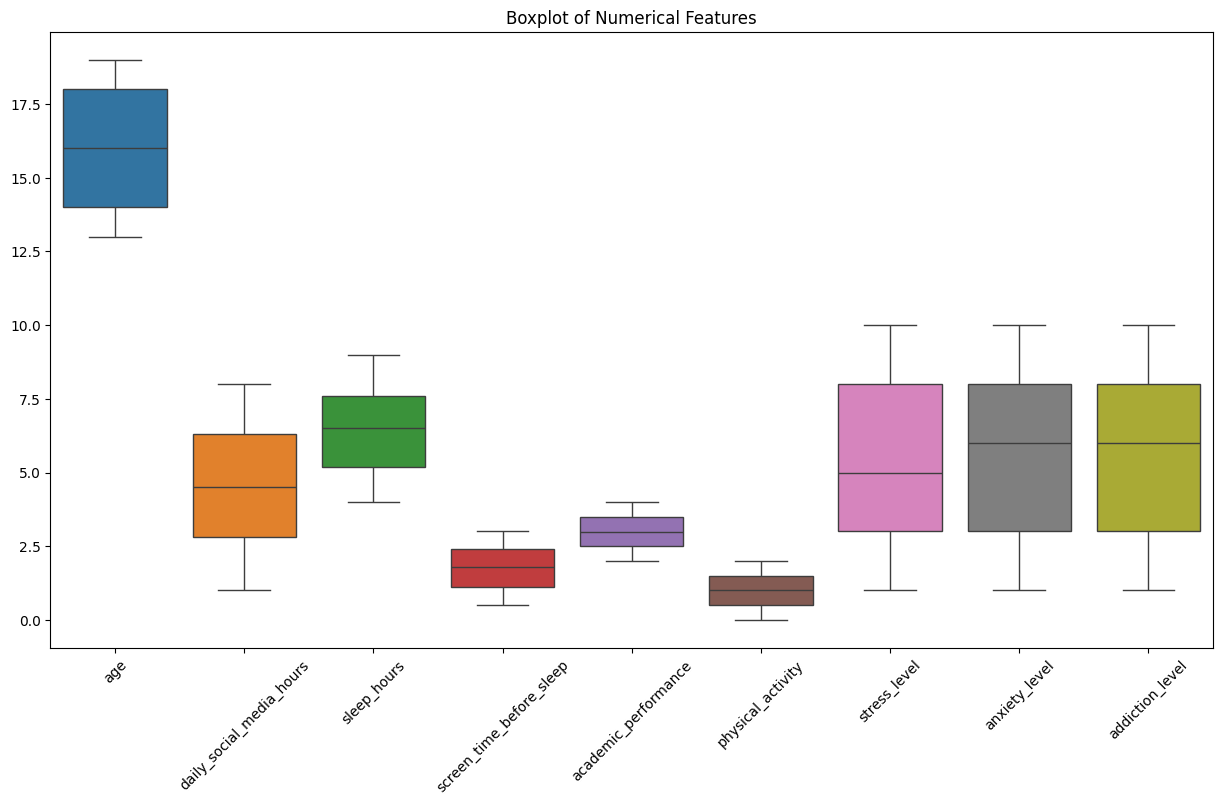

In [24]:
display(df_teen.isnull().sum())
display(df_teen.duplicated().sum())
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_teen[
    ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance','physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
])
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=45)
plt.show()




## 3. Оцените распредление числовых данных и частоту встречаемости категориальных

### Вопросы:
- Есть ли перекосы?
- Какие значения встречаются чаще всего?


In [43]:
df_stress = df_teen.groupby(['age', 'gender'])['stress_level'].mean().reset_index()
display(df_stress)
px.bar(df_stress, x='age', y='stress_level', color='gender', barmode='group', title='Stress Level by Age and Gender').show()


,age,gender,stress_level
0,13,female,5.333333
1,13,male,5.570093
2,14,female,5.923077
3,14,male,6.440000
4,15,female,5.483146
5,15,male,4.791209
6,16,female,5.610390
7,16,male,5.313953
8,17,female,5.164948
9,17,male,5.178082


In [55]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# --- Данные ---
ages_sorted = sorted(df_teen['age'].unique())

# Row 1 Bar: размер выборки по возрасту и полу
sample_age = df_teen.groupby(['age', 'gender']).size().reset_index(name='count')
sample_f = sample_age[sample_age['gender'] == 'female']
sample_m = sample_age[sample_age['gender'] == 'male']

# Row 2 Bar: средний stress_level по возрасту и полу
stress_age = df_teen.groupby(['age', 'gender'])['stress_level'].mean().reset_index()
stress_f = stress_age[stress_age['gender'] == 'female']
stress_m = stress_age[stress_age['gender'] == 'male']

# Row 3 Bar: количество записей с "позитивной" меткой депрессии по возрасту и полу
positive_label = sorted(df_teen['depression_label'].unique())[-1]
depr_age = (
    df_teen[df_teen['depression_label'] == positive_label]
    .groupby(['age', 'gender'])
    .size()
    .reset_index(name='count')
)
depr_f = depr_age[depr_age['gender'] == 'female']
depr_m = depr_age[depr_age['gender'] == 'male']

# Pie row 2: средний stress_level по полу
stress_by_gender = df_teen.groupby('gender')['stress_level'].mean().reset_index()

# Pie row 3: распределение меток depression_label + читаемые подписи
depr_counts = df_teen['depression_label'].value_counts().reset_index()
depr_counts.columns = ['label', 'count']
label_map = {0: 'No depression', 1: 'Depression'}
depr_counts['label_text'] = depr_counts['label'].map(label_map).fillna(depr_counts['label'].astype(str))
color_map = {'No depression': 'steelblue', 'Depression': 'tomato'}
depr_counts['color'] = depr_counts['label_text'].map(color_map).fillna('gray')

# --- Subplot: верхний bar на всю ширину ---
fig = make_subplots(
    rows=3,
    cols=2,
    column_widths=[0.7, 0.3],
    subplot_titles=[
        'Sample Size by Age & Gender', '',
        'Avg Stress Level by Age & Gender', 'Avg Stress Level by Gender',
        f'Depression ({label_map.get(positive_label, positive_label)}) by Age & Gender',
        'Depression Label Distribution (%)'
    ],
    specs=[
        [{"type": "bar", "colspan": 2}, None],
        [{"type": "bar"}, {"type": "pie"}],
        [{"type": "bar"}, {"type": "pie"}],
    ]
)

# Row 1 Bar (span 2 columns)
fig.add_trace(
    go.Bar(x=sample_f['age'], y=sample_f['count'], name='female', marker_color='steelblue', legendgroup='female'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=sample_m['age'], y=sample_m['count'], name='male', marker_color='tomato', legendgroup='male'),
    row=1, col=1
)

# Row 2 Bar
fig.add_trace(
    go.Bar(x=stress_f['age'], y=stress_f['stress_level'], name='female', marker_color='steelblue', legendgroup='female', showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=stress_m['age'], y=stress_m['stress_level'], name='male', marker_color='tomato', legendgroup='male', showlegend=False),
    row=2, col=1
)

# Row 2 Pie: без цикла, avg берем из customdata
fig.add_trace(
    go.Pie(
        labels=stress_by_gender['gender'],
        values=stress_by_gender['stress_level'],
        customdata=stress_by_gender[['stress_level']],
        texttemplate='%{label}<br>avg: %{customdata[0]:.2f}<br>%{percent}',
        textposition='inside',
        hovertemplate='%{label}<br>avg: %{customdata[0]:.2f}<br>%{percent}<extra></extra>',
        marker_colors=['steelblue', 'tomato'],
        showlegend=False,
        name='Stress'
    ),
    row=2, col=2
)

# Row 3 Bar
fig.add_trace(
    go.Bar(x=depr_f['age'], y=depr_f['count'], name='female', marker_color='steelblue', legendgroup='female', showlegend=False),
    row=3, col=1
)
fig.add_trace(
    go.Bar(x=depr_m['age'], y=depr_m['count'], name='male', marker_color='tomato', legendgroup='male', showlegend=False),
    row=3, col=1
)

# Row 3 Pie: поворот + подписи без 0/1 + единая палитра
fig.add_trace(
    go.Pie(
        labels=depr_counts['label_text'],
        values=depr_counts['count'],
        marker_colors=depr_counts['color'],
        textposition='outside',
        textinfo='label+percent',
        rotation=120,
        showlegend=False,
        name='Depression'
    ),
    row=3, col=2
)

# Чтобы в bar были видны все возраста на оси X
for r in [1, 2, 3]:
    fig.update_xaxes(
        row=r,
        col=1,
        type='category',
        categoryorder='array',
        categoryarray=ages_sorted
    )

fig.update_layout(
    height=1050,
    barmode='group',
    title_text='Stress & Depression by Gender and Age',
    legend_title_text='Gender'
)
fig.show()


## 4. Оцените зависмости переменных друг на друга

### Вопросы:
- Есть ли корреляции?
- Что влияет на депрессию?


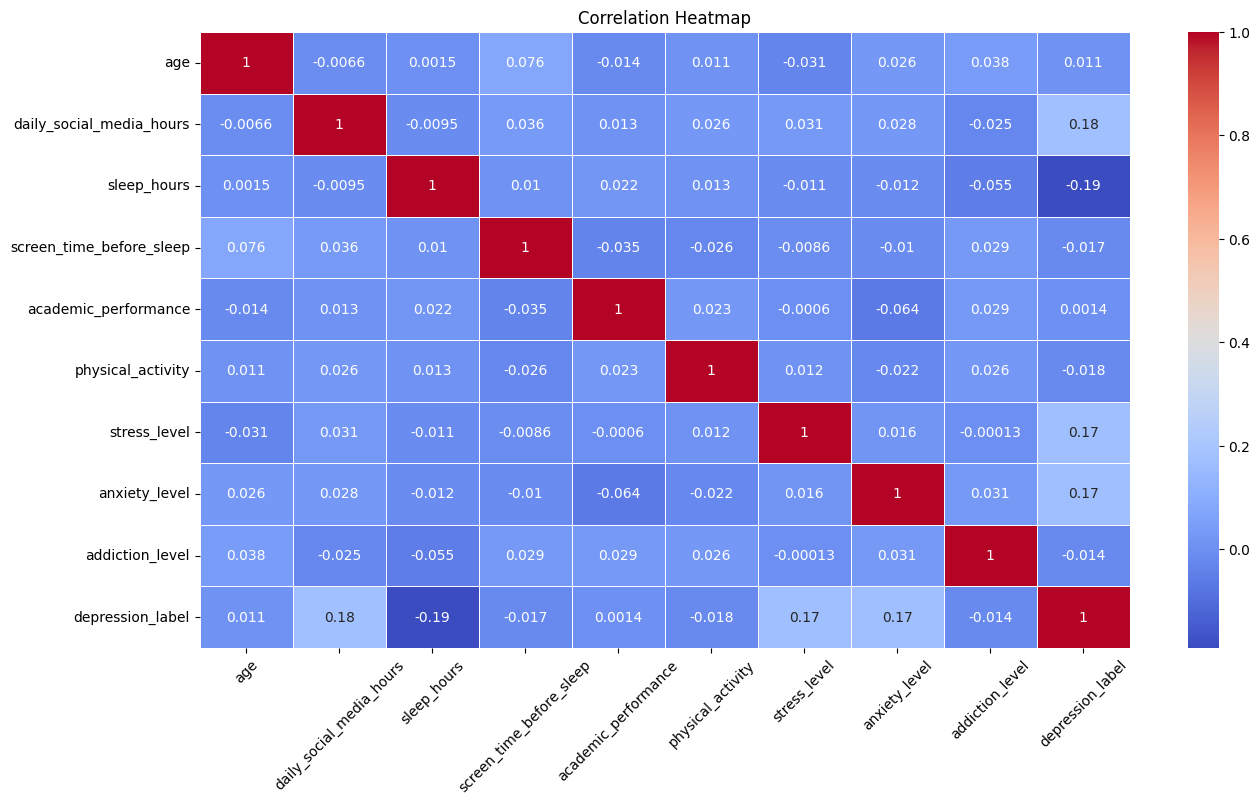

In [15]:
corr = df_teen.select_dtypes(include=['int64', 'float64']).corr()
corr
plt.figure(figsize=(15, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.xticks(rotation=45)
plt.title('Correlation Heatmap')
plt.show()

## 5. Выводы
Сформулируйте:
- 3-5 инсайтов
- 1-2 рекомендации

In [ ]:
del df_derpession['gender']
del df_derpession['platform_usage']
del df_derpession['social_interaction_level']
df_derpession

In [ ]:
#df['Gender_Encoded'] = pd.factorize(df['Gender'])[0]
df_derpession['gender_code']  = pd.factorize(df_derpession['gender'])[0]
df_derpession['platform_usage_code'] = pd.factorize(df_derpession['platform_usage'])[0]
df_derpession['social_interaction_level_code'] = pd.factorize(df_derpession['social_interaction_level'])[0]
df_derpession